In [1]:
#impot libraries and packeges
import io
import os
import cv2 
import PIL.Image
import pytesseract
import numpy as np
from pytesseract import Output
from matplotlib import pyplot as plt
from IPython.display import clear_output, Image, display

In [2]:
#defining the image path
pytesseract.pytesseract.tesseract_cmd = 'C:/Program Files/Tesseract-OCR/tesseract.exe'
IMG_DIR = 'dataset/'

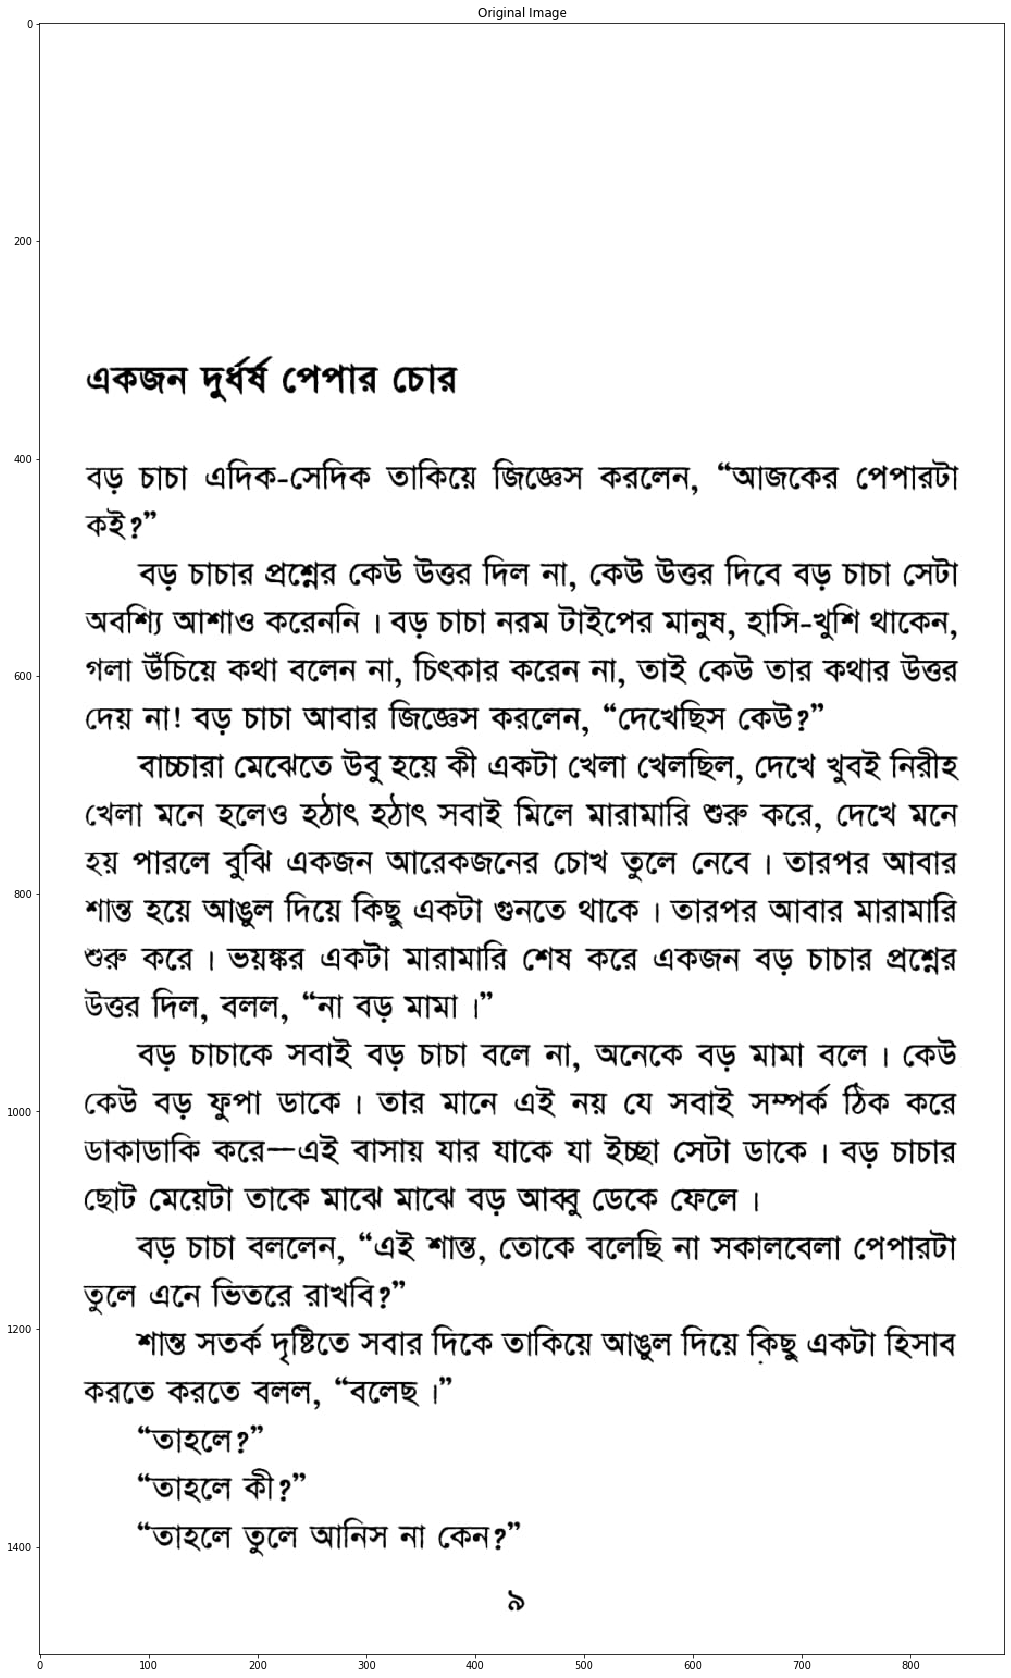

In [3]:
#taking input
image = cv2.imread(IMG_DIR + 'img1.jpg')

plt.figure(figsize=(30,30))
plt.title('Original Image')
plt.imshow(image)
plt.show()

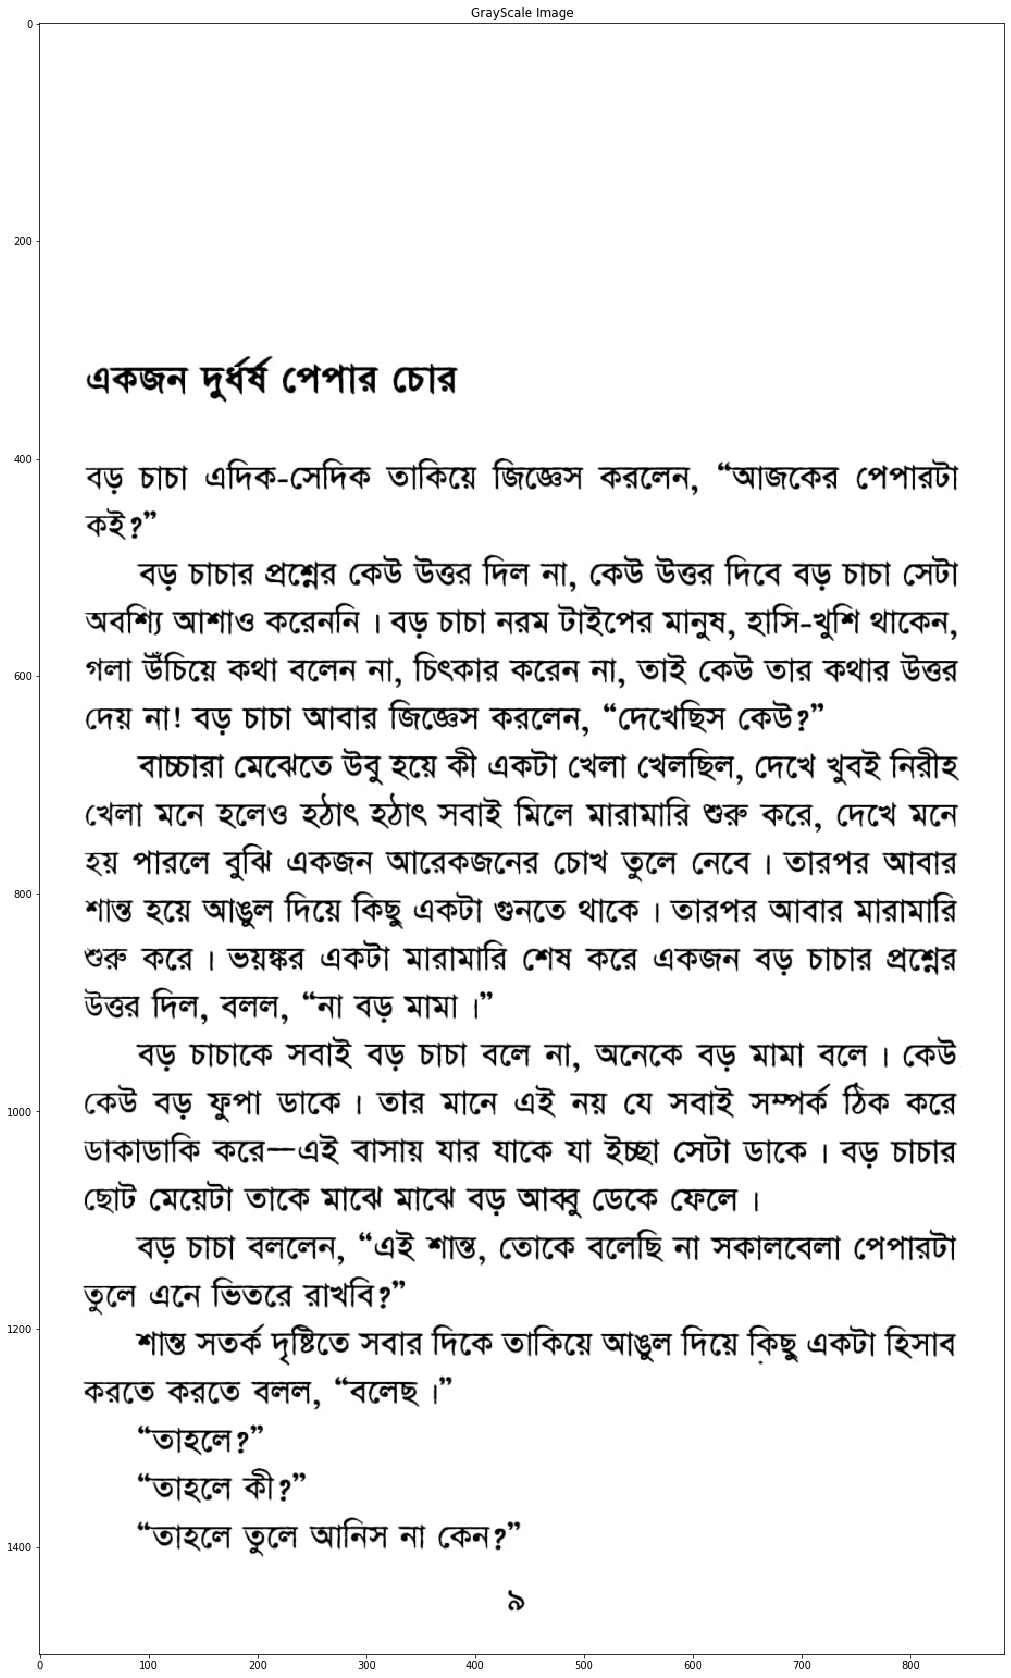

In [4]:
#applying greyscale filter
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(30,30))
plt.title('GrayScale Image')
plt.imshow(gray, cmap='gray')
plt.show()

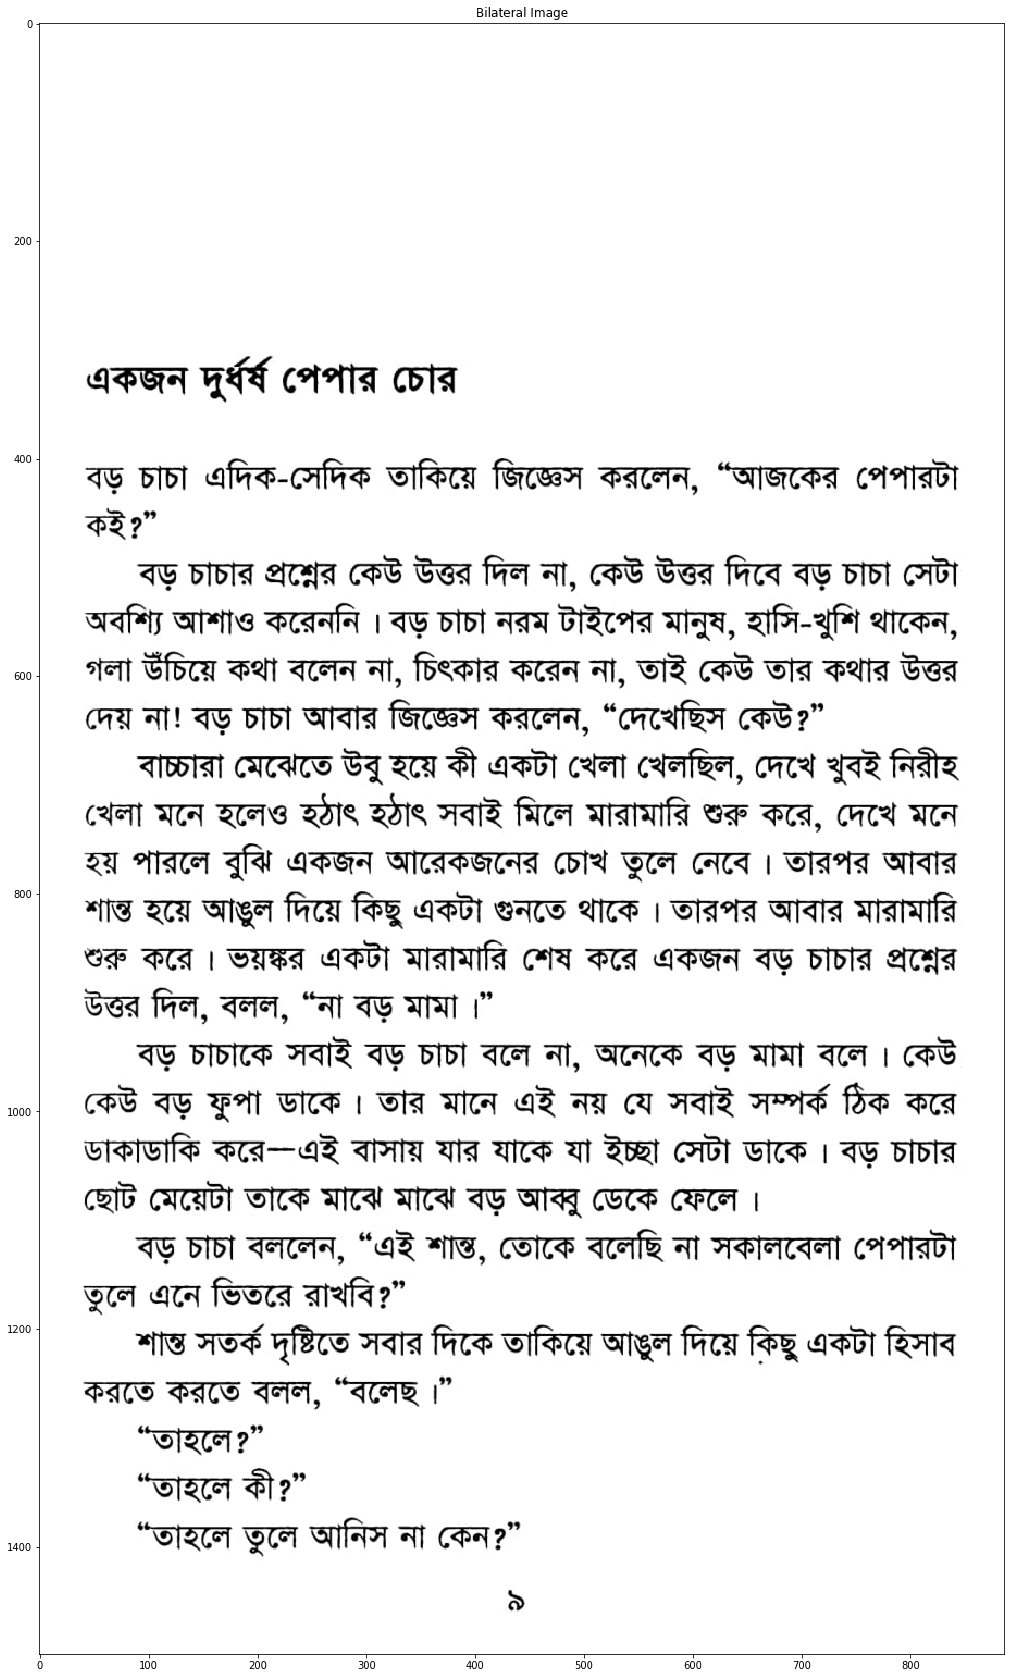

In [5]:
#applying bilateral filter
bilateral = cv2.bilateralFilter(gray, 15, 75, 75)

plt.figure(figsize=(30,30))
plt.title('Bilateral Image')
plt.imshow(gray, cmap='gray')
plt.show()

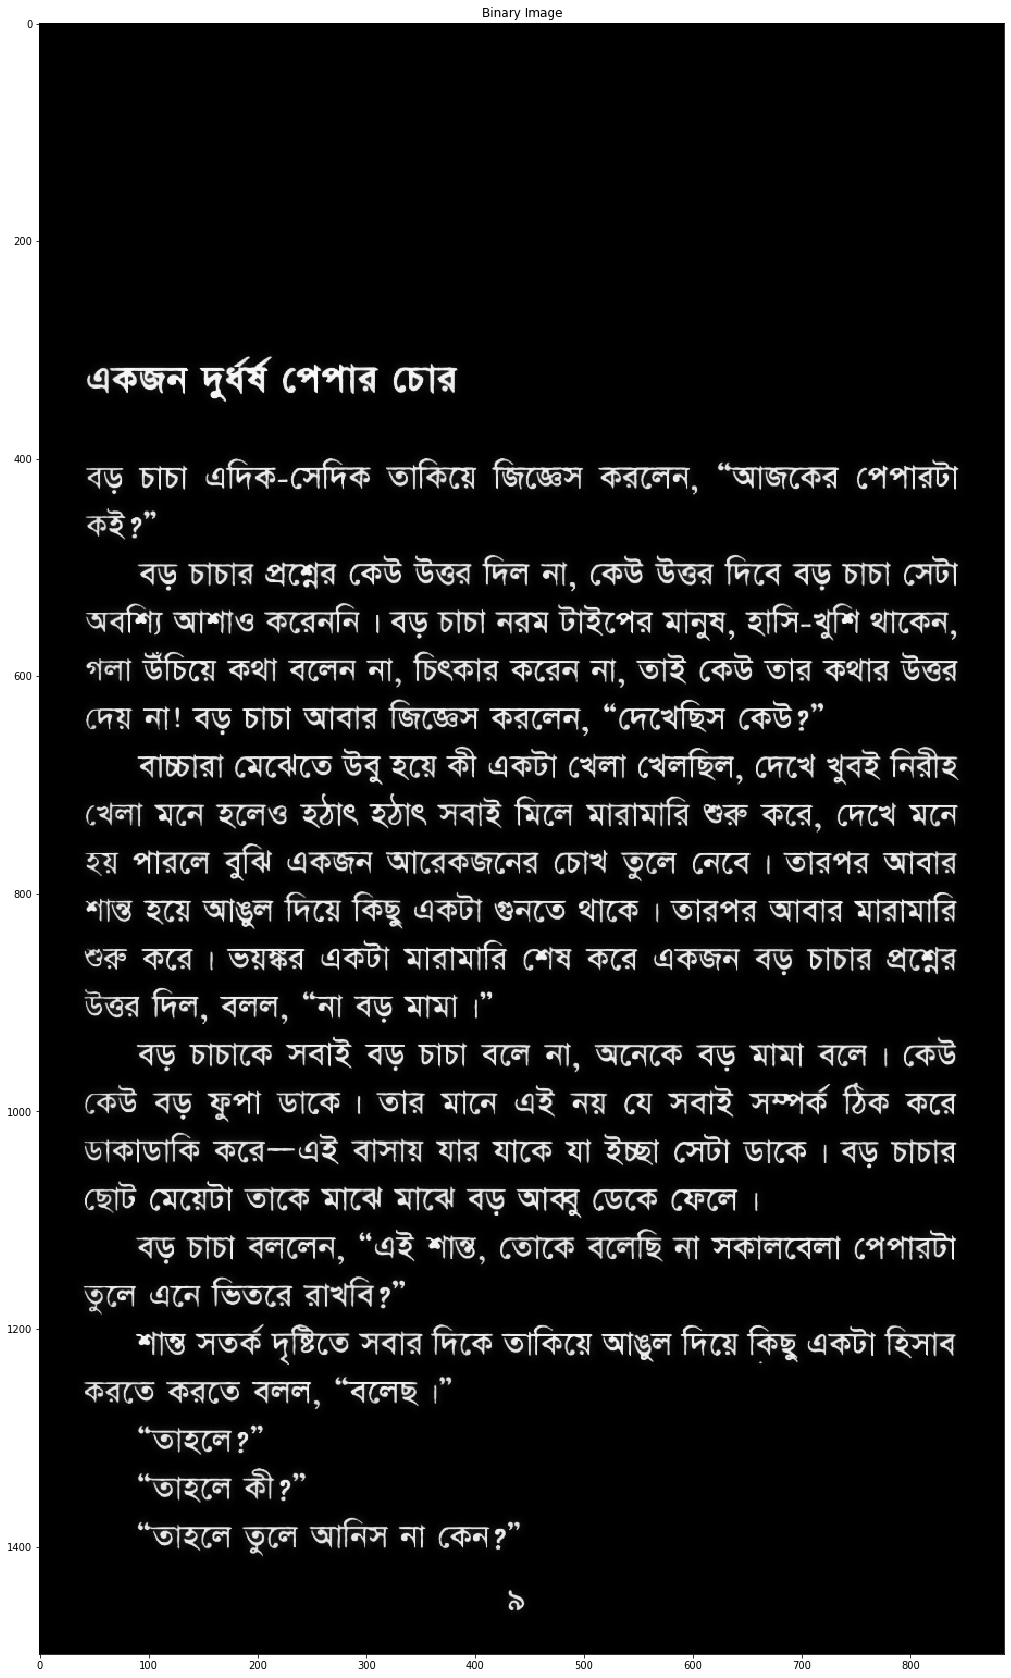

In [6]:
#applying bit plane slicing or getting binary image
binary_image = cv2.bitwise_not(bilateral)
thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_OTSU)

plt.figure(figsize=(30,30))
plt.title('Binary Image')
plt.imshow(binary_image, cmap = "gray")
plt.show()

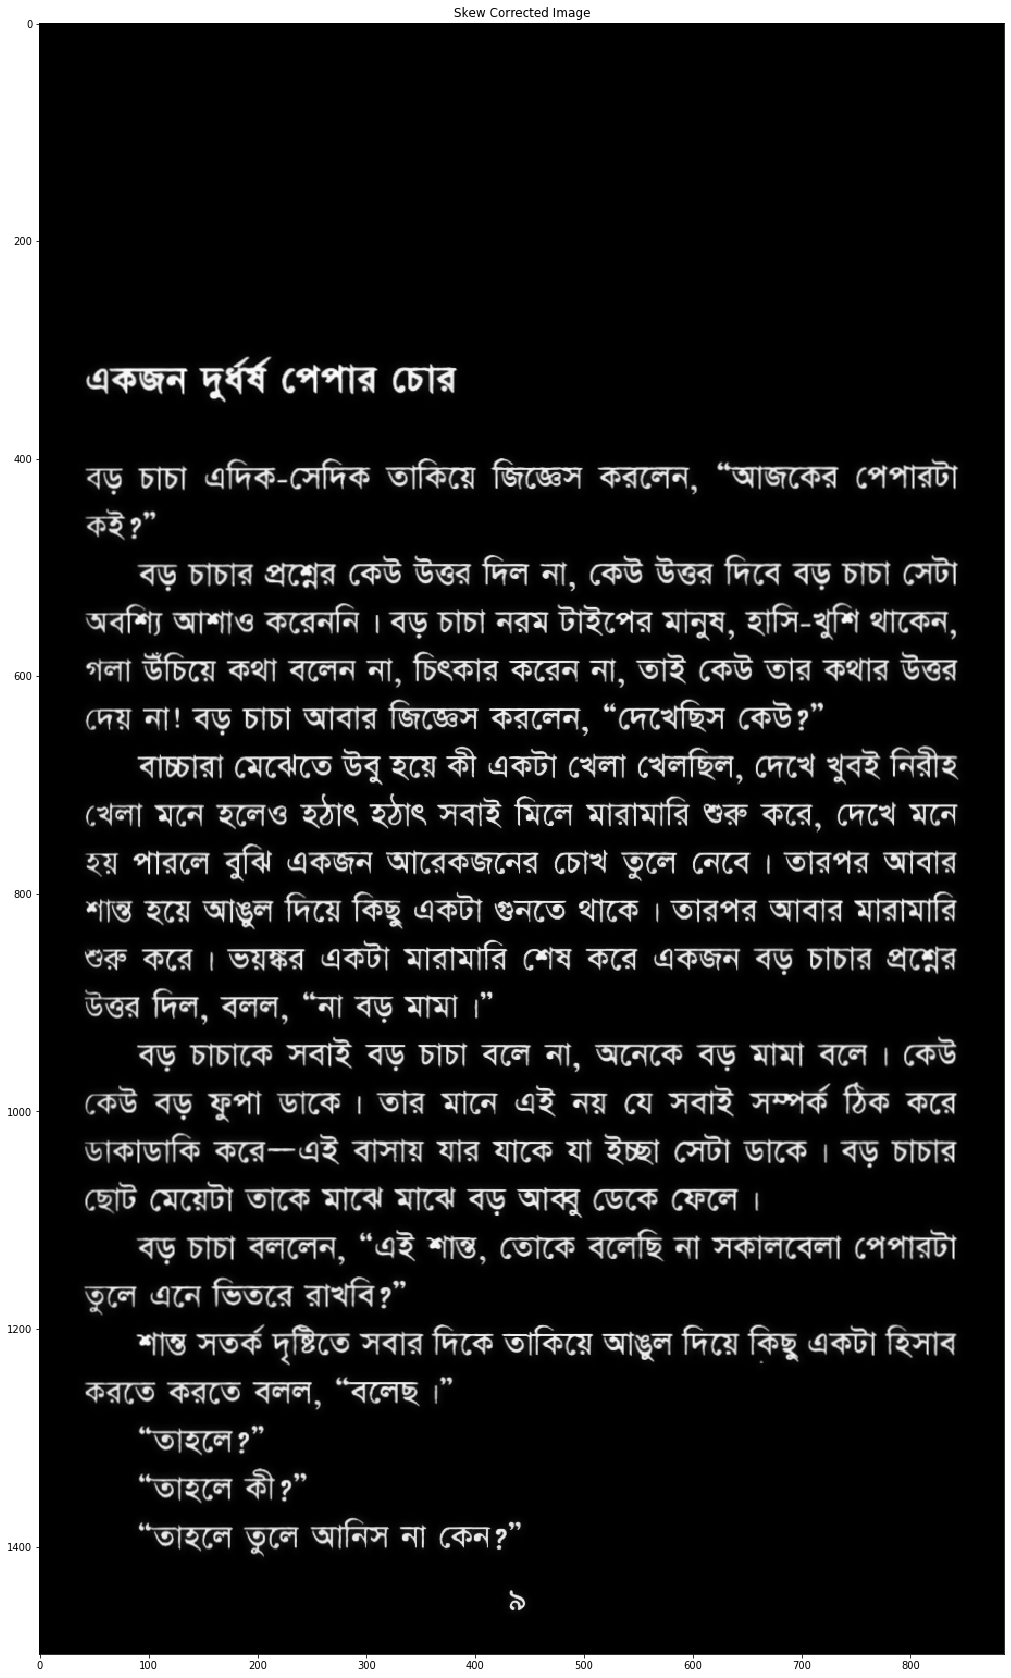

In [7]:
#applying skew angle correction
coords = np.column_stack(np.where(binary_image > 0))
angle = cv2.minAreaRect(coords)[-1]
if angle < -45:
	angle = -(90 + angle)
else:
	angle = -angle
(h, w) = binary_image.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, angle, 1.0)
rotated_image = cv2.warpAffine(binary_image, M, (w, h))

plt.figure(figsize=(30,30))
plt.title('Skew Corrected Image')
plt.imshow(rotated_image, cmap = "gray")
plt.show()

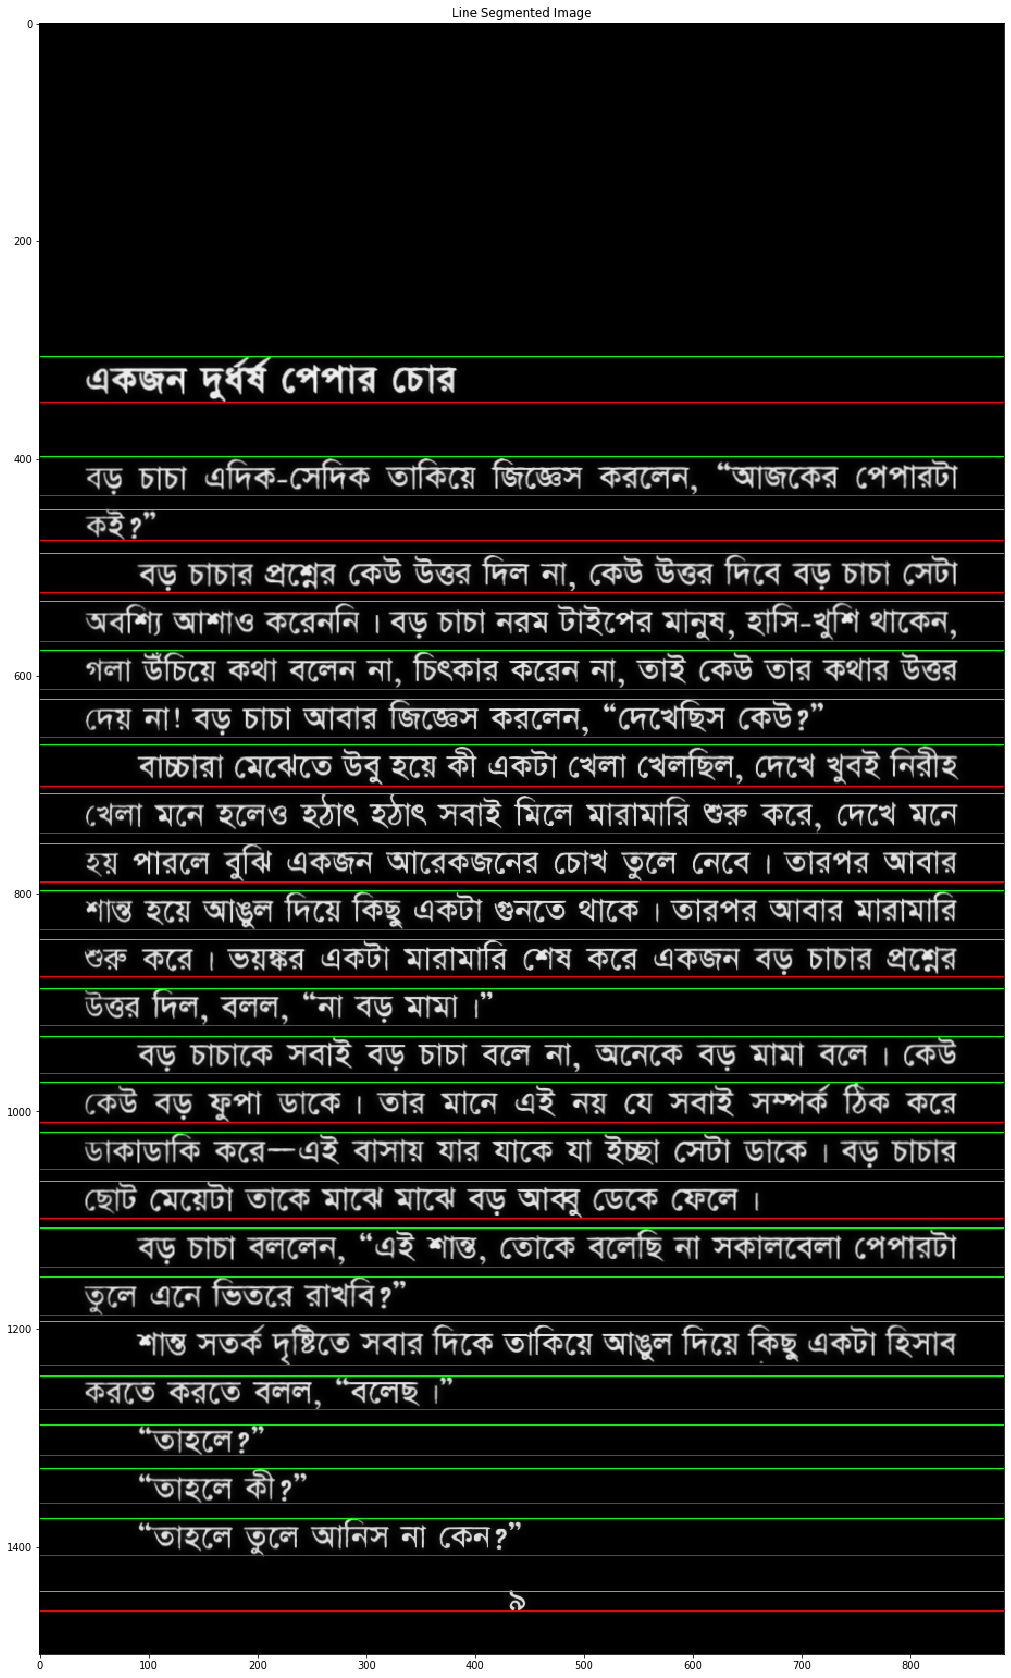

In [8]:
hist = cv2.reduce(rotated_image,1, cv2.REDUCE_AVG).reshape(-1)
output = cv2.cvtColor(rotated_image, cv2.COLOR_GRAY2BGR)
upper = 0
lower = len(hist)-1
while hist[upper] <= min(hist):
    upper+=1
while hist[lower] <= min(hist):
    lower-=1
x = upper
prev_x = upper
while x < lower:
    while x < len(hist) and hist[x] <= min(hist):
        x += 1
    prev_x = x
    while x < len(hist) and hist[x] > min(hist):
        x += 1
    if x - prev_x > 10:
        cv2.line(output, (0, x),(w, x), (255,0,0),1)
        cv2.line(output, (0, prev_x),(w, prev_x), (0,255,0),1)
    
plt.figure(figsize=(30,30))
plt.title('Line Segmented Image')
plt.imshow(output)
plt.show()

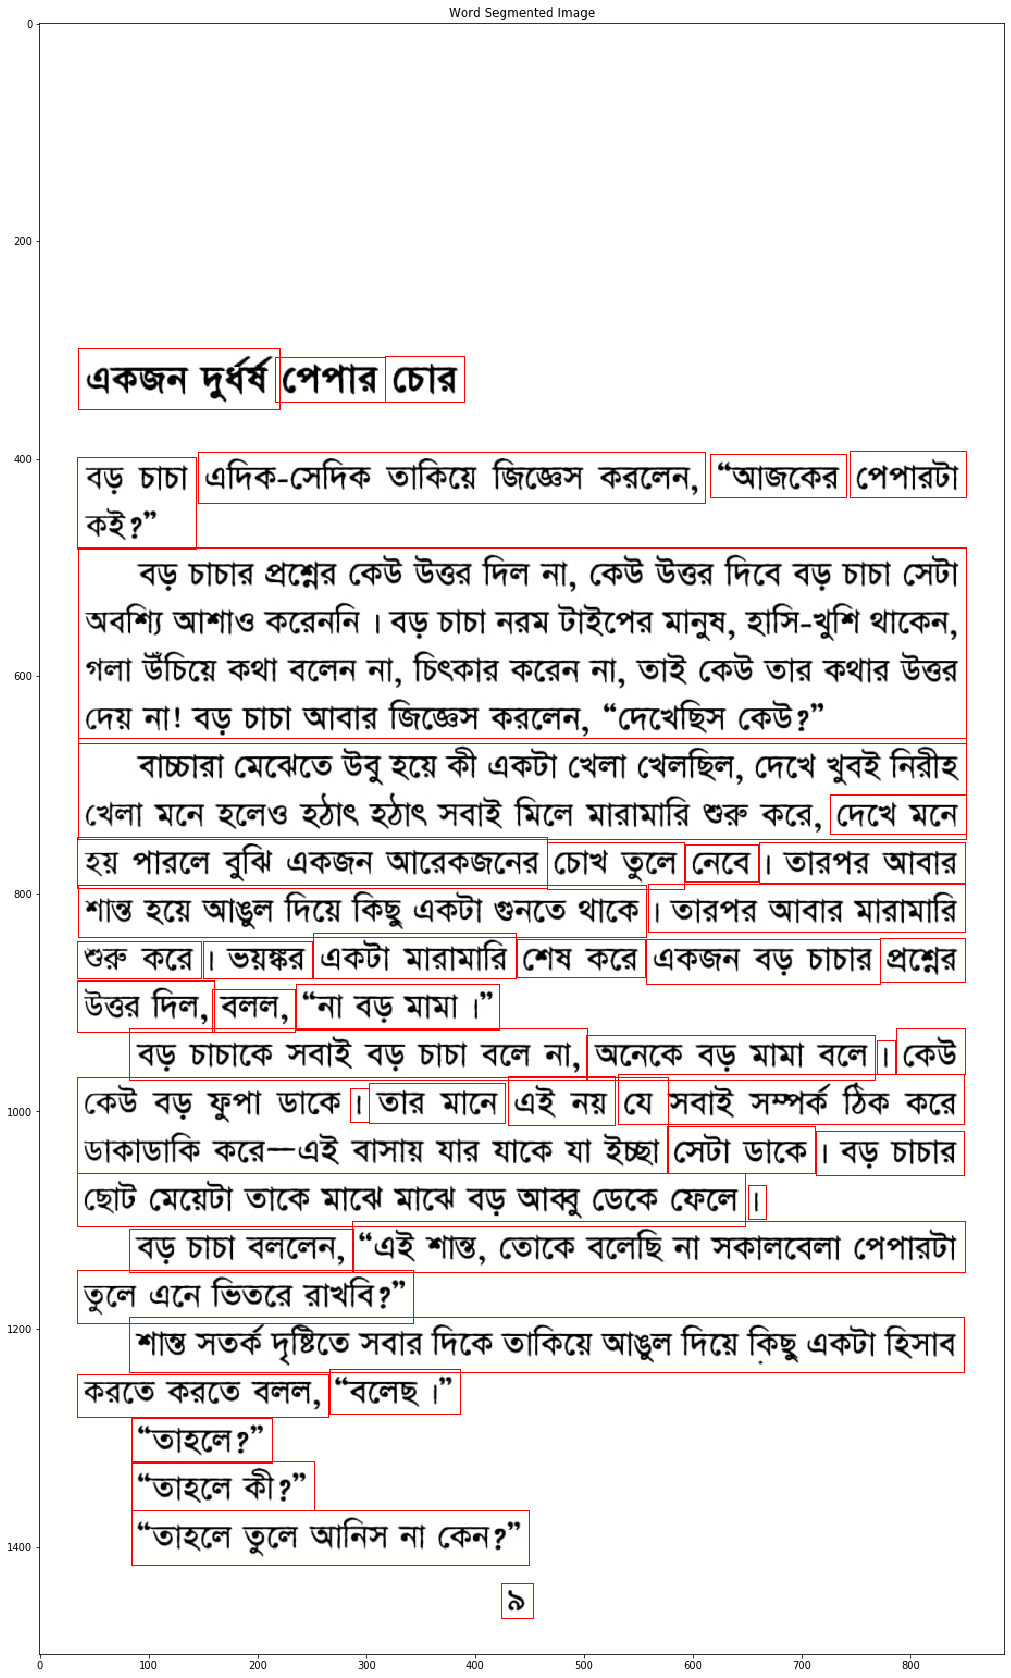

In [9]:
contours, hierarchy = cv2.findContours(rotated_image,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE) 

     
for contour in contours: 
    [x,y,w,h] = cv2.boundingRect(contour)

    if w <1 and h<1:    
        continue

    cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,0),1)

plt.figure(figsize=(30,30))
plt.imshow(image)
plt.title('Word Segmented Image')
plt.show()

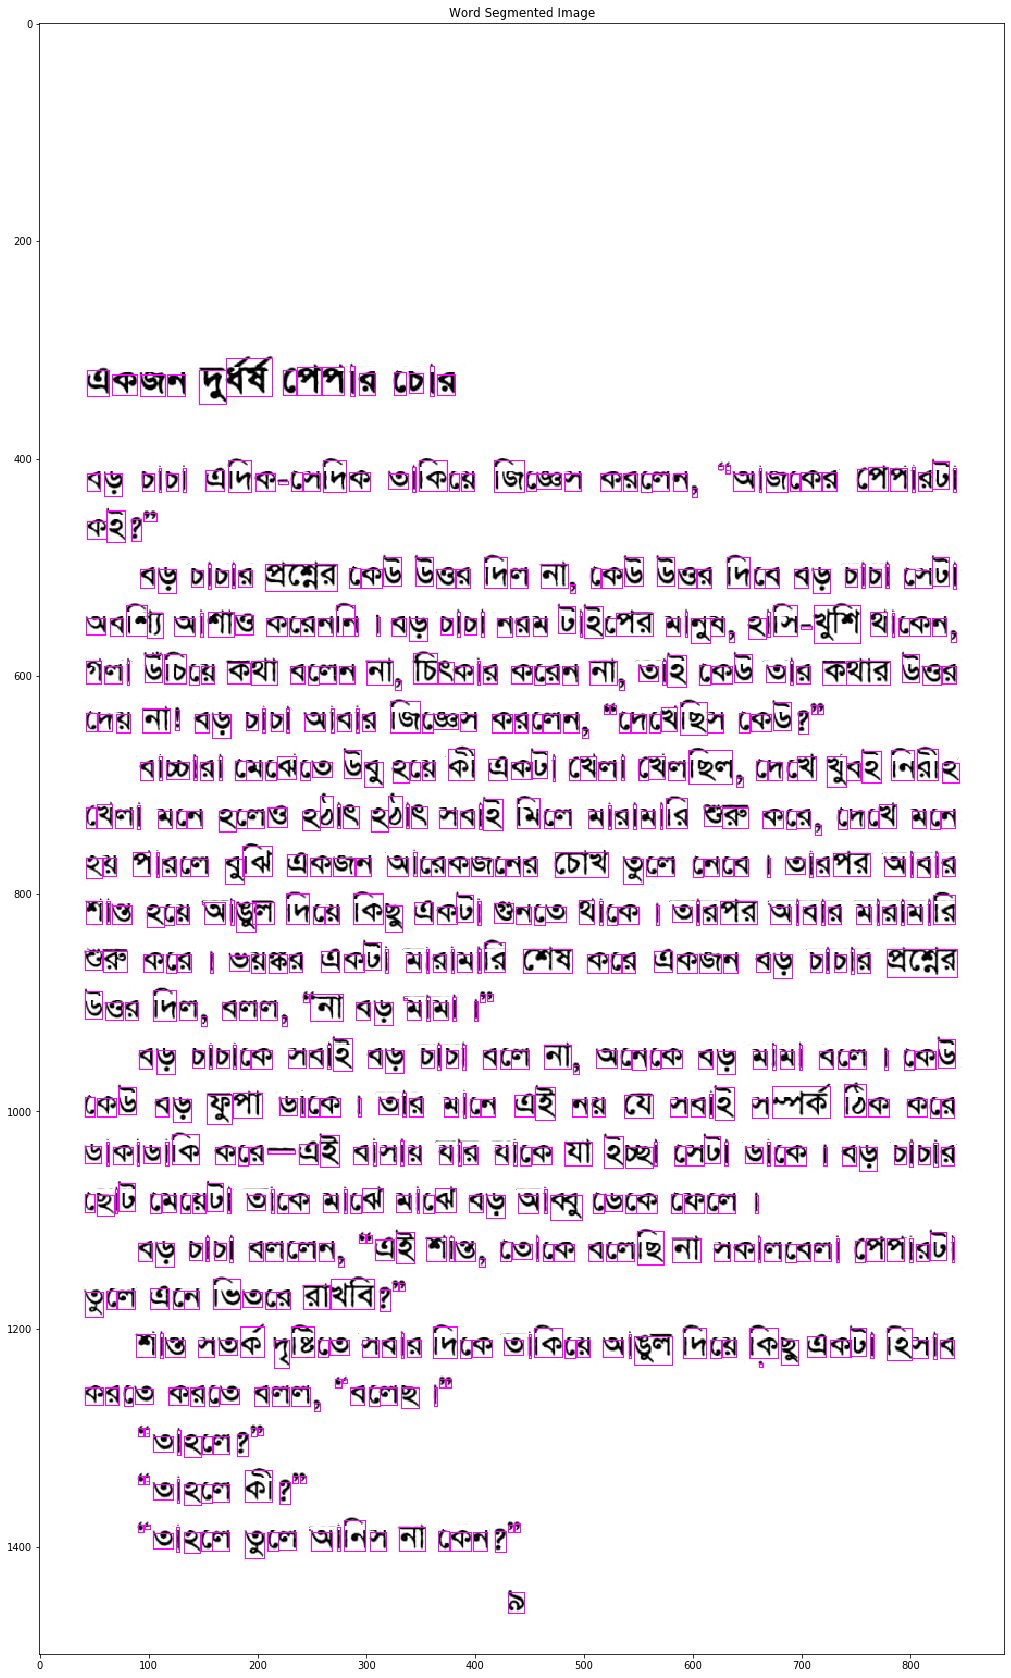

In [31]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
IMG_DIR = 'dataset/'


image = cv2.imread(IMG_DIR + 'img1.jpg')
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# Remove horizontal
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,1))
detected_lines = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
cnts = cv2.findContours(detected_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = cnts[0] if len(cnts) == 2 else cnts[1]
for c in cnts:
    cv2.drawContours(image, [c], -1, (255,255,255), 2)

# Repair image
repair_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,6))
result = 255 - cv2.morphologyEx(255 - image, cv2.MORPH_CLOSE, repair_kernel, iterations=2)

result=cv2.cvtColor(result, cv2.COLOR_BGR2GRAY);
result = cv2.threshold(result, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
contours, hierarchy = cv2.findContours(result,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_NONE) 

     
for contour in contours: 
    [x,y,w,h] = cv2.boundingRect(contour)

    if w <1 and h<1:    
        continue

    cv2.rectangle(image,(x,y),(x+w,y+h),(255,0,255),1)


plt.figure(figsize=(30,30))
plt.imshow(image)
plt.title('Word Segmented Image')
plt.show()